# Processus Aléatoires (Ex 3.1)
M.Tognolini - feb. 2026 HEIG-VD rev 1.1 

# 1. Configuration de l'environnement

# Fiche de Révision : Analyse des Processus Aléatoires

Cette fiche traite de la caractérisation statistique des signaux aléatoires, de la stationnarité, de l'ergodicité et de l'analyse spectrale.

---

## 1. Définitions Fondamentales

Un **processus aléatoire** $X(n, \zeta)$ peut être vu comme une famille de fonctions du temps (appelées réalisations). Pour un instant $n$ fixé, $X(n)$ est une variable aléatoire.

### A. Moyenne d'ensemble (Espérance)
La moyenne d'ensemble est la moyenne pondérée par la probabilité de toutes les réalisations possibles à un instant $n$ précis :
$$E[X(n)] = \int_{-\infty}^{+\infty} x f_{X_n}(x) dx$$
Pour un signal de type $X(n) = A \cos(2\pi f_0 n + \Phi)$ où $\Phi$ suit une loi uniforme sur $[0, 2\pi]$, l'espérance est nulle car l'intégration d'un cosinus sur sa période est nulle.

### B. Autocorrélation d'ensemble
Elle mesure la dépendance linéaire entre deux échantillons du même processus à deux instants différents $n_1$ et $n_2$ :
$$R_{XX}(n_1, n_2) = E[X(n_1)X(n_2)]$$

---

## 2. Stationnarité au Sens Large (SSL)

Un processus est dit **Stationnaire au Sens Large (SSL)** si ses propriétés statistiques du second ordre sont invariantes par translation dans le temps. Cela nécessite deux conditions :

1.  **Moyenne constante** : $E[X(n)] = m_X$ (ne dépend pas de $n$).
2.  **Autocorrélation invariante** : $R_{XX}(n, n+k)$ ne dépend que du décalage (lag) $k$, et non de l'instant absolu $n$. On note alors :
    $$R_{XX}(k) = E[X(n)X(n+k)]$$

> **Note théorique** : Pour une sinusoïde, la phase aléatoire $\Phi$ uniforme sur $[0, 2\pi]$ est la condition sine qua non pour rendre le processus stationnaire. Sans cette phase aléatoire, le signal est déterministe et sa moyenne dépendrait du temps.

---

## 3. Ergodicité

Un processus est **ergodique** si ses moyennes temporelles (calculées sur une seule réalisation très longue) convergent vers ses moyennes d'ensemble.

### A. Moyenne temporelle
$$\langle X(n) \rangle = \lim_{N \to \infty} \frac{1}{N} \sum_{n=0}^{N-1} x(n)$$

### B. Autocorrélation temporelle
$$\hat{R}_{XX}(k) = \lim_{N \to \infty} \frac{1}{N} \sum_{n=0}^{N-1} x(n)x(n+k)$$

**Interprétation du Notebook** : Dans vos exercices, vous comparez graphiquement $R_{XX}(k)$ (moyenne sur 1000 réalisations) et $\hat{R}_{XX}(k)$ (calculé sur une seule courbe). La superposition des deux courbes valide l'hypothèse d'ergodicité.

---

## 4. Somme de Processus Indépendants

Soit $y(n) = y_h(n) + v(n)$, où $y_h$ est un signal harmonique et $v$ un bruit blanc. Si ces deux processus sont **indépendants et de moyennes nulles**, alors l'autocorrélation de la somme est égale à la somme des autocorrélations :
$$R_{yy}(k) = R_{y_h y_h}(k) + R_{vv}(k)$$

### Le cas du Bruit Blanc Gaussien
Le bruit blanc est un processus où chaque échantillon est totalement indépendant du précédent. Son autocorrélation est une impulsion (Dirac) à $k=0$ :
$$R_{vv}(k) = \sigma_v^2 \delta(k)$$
* Si $k=0$, $R_{vv}(0) = \sigma_v^2$ (Puissance du bruit).
* Si $k \neq 0$, $R_{vv}(k) = 0$.

C'est pourquoi, sur vos graphiques, l'autocorrélation du signal bruité présente un pic très net au centre, qui "porte" les oscillations du signal harmonique.

---

## 5. Densité Spectrale de Puissance (DSP)

La DSP, notée $S_{XX}(f)$, décrit la répartition de la puissance du signal en fonction de la fréquence.

### A. Théorème de Wiener-Khinchin
Pour un processus SSL, la DSP est la Transformée de Fourier de la fonction d'autocorrélation :
$$S_{XX}(f) = \mathcal{F}\{R_{XX}(k)\} = \sum_{k=-\infty}^{+\infty} R_{XX}(k) e^{-j 2\pi f k}$$

### B. Propriétés de la DSP
* **Positivité** : $S_{XX}(f) \geq 0$ toujours.
* **Symétrie** : Pour un signal réel, $S_{XX}(f) = S_{XX}(-f)$.
* **Puissance totale** : L'aire sous la courbe de la DSP correspond à la puissance moyenne du signal (valeur de l'autocorrélation à $k=0$).

### C. L'échelle Logarithmique (Décibels)
Pour visualiser des signaux ayant des ordres de grandeur très différents (un pic harmonique puissant et un bruit de fond très faible), on utilise l'échelle en dB :
$$S_{dB}(f) = 10 \log_{10}(S_{XX}(f))$$
Cette transformation permet de voir le "plancher de bruit" qui serait autrement écrasé sur une échelle linéaire.

---

## Synthèse des résultats attendus dans le TP

1.  **Graphique Moyenne/Variance** : La moyenne doit tendre vers 0 et la variance doit être constante ($\approx A^2/2$). Preuve de stationnarité.
2.  **Graphique Autocorrélation** : Doit montrer une décroissance (si l'estimateur est biaisé) ou une forme périodique. Le pic à $k=0$ donne la puissance totale.
3.  **Graphique DSP** : Doit montrer des pics aux fréquences $f_0/m$ correspondant aux composantes harmoniques et un plateau horizontal correspondant au bruit blanc.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


## 2. Génération du Processus Aléatoire
Un processus aléatoire X(n,ζ) est une famille de fonctions du temps. Nous générons ici N réalisations de longueur L. Un exemple classique de cet exercice est un processus sinusoïdal avec une phase aléatoire ϕ uniformément distribuée sur [0,2π].

$X(n)=Acos(ω_0 n+ϕ)$

L'exercice porte généralement sur la génération de multiples réalisations (chemins) d'un processus et l'analyse de ses propriétés statistiques (moyenne d'ensemble vs moyenne temporelle).  Nous utilisons des fonctions de génération de nombres aléatoires pour créer ces réalisations et les stocker dans une matrice. Chaque colonne de la matrice représente une réalisation du processus, tandis que chaque ligne correspond à un instant de temps. La phase de la fonction cos est également randomisée pour chaque réalisation afin de simuler un processus aléatoire.

Pour  générer un processus sinusoïdal avec une phase aléatoire, nous pouvons utiliser la fonction `numpy.random.uniform` pour générer des phases aléatoires et `numpy.cos` pour créer les réalisations du processus. Voici un exemple de code pour générer un tel processus :

Pour  avoir toujours la même  séquence  aléatoire à chaque exécution, nous pouvons fixer la graine du générateur de nombres aléatoires avec `numpy.random.seed`. Cela garantit que les résultats sont reproductibles.

```python
import numpy as np
import matplotlib.pyplot as plt 
# Paramètres du processus
A = 1.0          # Amplitude
f0 = 0.1         # Fréquence normalisée (cycles par échantillon)
N = 100          # Nombre d'échantillons par réalisation
NR = 50          # Nombre de réalisations
# Fixer la graine pour la reproductibilité
np.random.seed(0)
# Générer des phases aléatoires uniformément distribuées entre 0 et 2π
phi = np.random.uniform(0, 2 * np.pi, NR)
# Générer les réalisations du processus
n = np.arange(N)  # Vecteur de temps
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi)  # Matrice de réalisations (N x NR)
# Afficher quelques réalisations
plt.figure(figsize=(12, 6))
for i in range(5):  # Afficher les 5 premières réalisations
    plt.plot(n, X[:, i], label=f'Réalisation {i+1}')
plt.title('Réalisation d\'un processus sinusoïdal avec phase aléatoire')
plt.xlabel('Temps (échantillons)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()
```

Ce code génère un processus sinusoïdal avec une phase aléatoire et affiche les premières réalisations. Chaque réalisation est une fonction du temps avec une phase différente, illustrant ainsi la nature aléatoire du processus.   

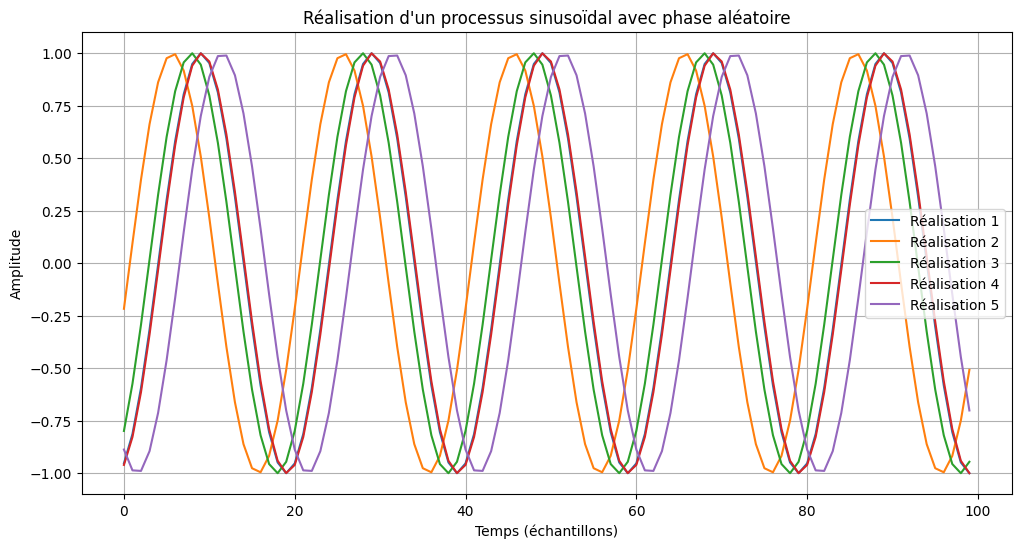

In [5]:
# Paramètres du processus
A = 1.0          # Amplitude
f0 = 0.05         # Fréquence normalisée (cycles par échantillon)
N = 100          # Nombre d'échantillons par réalisation
NR = 100          # Nombre de réalisations
# Fixer la graine pour la reproductibilité
np.random.seed(0)
# Générer des phases aléatoires uniformément distribuées entre 0 et 2π
phi = np.random.uniform(0, 2 * np.pi, NR)
# Générer les réalisations du processus
n = np.arange(N)  # Vecteur de temps
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi)  # Matrice de réalisations (N x NR)
# Afficher quelques réalisations
plt.figure(figsize=(12, 6))
for i in range(5):  # Afficher les 5 premières réalisations
    plt.plot(n, X[:, i], label=f'Réalisation {i+1}')
plt.title('Réalisation d\'un processus sinusoïdal avec phase aléatoire')
plt.xlabel('Temps (échantillons)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

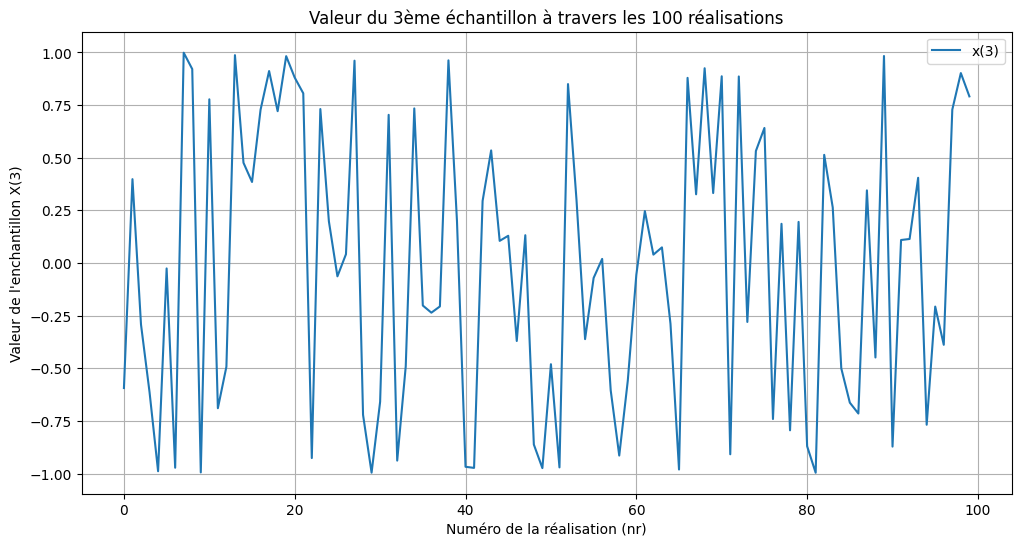

In [10]:
sample3 = X[2, :]
nr = np.arange(sample3.shape[0])
plt.figure(figsize=(12, 6))
plt.plot(nr, sample3, label = 'x(3)')
plt.title('Valeur du 3ème échantillon à travers les 100 réalisations')
plt.xlabel('Numéro de la réalisation (nr)')
plt.ylabel("Valeur de l'enchantillon X(3)")
plt.legend()
plt.grid()
plt.show()

Les 5 premières valeurs de la réalisation 1 :
[-0.95333378 -0.8133764  -0.59380006 -0.31609844 -0.00745491]


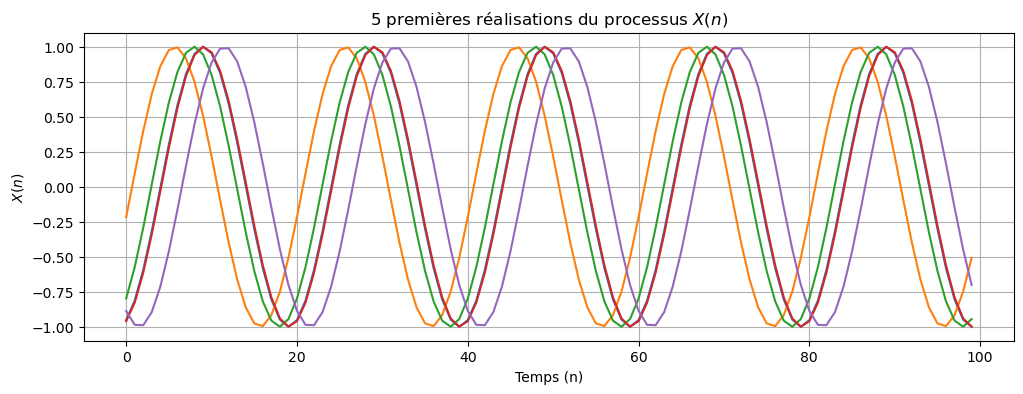

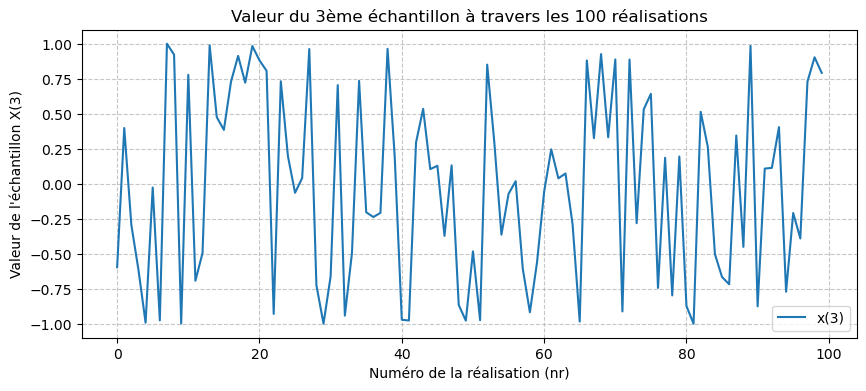

In [43]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 3. Statistiques d'Ensemble
La moyenne d'ensemble (Ensemble Mean) est calculée en faisant la moyenne de toutes les réalisations à un instant n donné :
$$μ_x(n) = E[X(n)] = (1/N) ∑_{i=1}^{N} X_i(n)$$

où X_i(n) est la i-ème réalisation du processus à l'instant n. La moyenne d'ensemble est un vecteur de taille n (nombre d'échantillons temporels). 

In [18]:
# Paramètres du processus
A = 1.0          # Amplitude
f0 = 0.05         # Fréquence normalisée (cycles par échantillon)
N = 1000          # Nombre d'échantillons par réalisation
NR = 1000          # Nombre de réalisations
# Fixer la graine pour la reproductibilité
np.random.seed(0)
# Générer des phases aléatoires uniformément distribuées entre 0 et 2π
phi = np.random.uniform(0, 2 * np.pi, NR)
# Générer les réalisations du processus
n = np.arange(N)  # Vecteur de temps
nr = np.arange(NR)
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi)  # Matrice de réalisations (N x NR)

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8998/790429090.py:19: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Variance d'ensemble $\sigma_X^2(n)$")


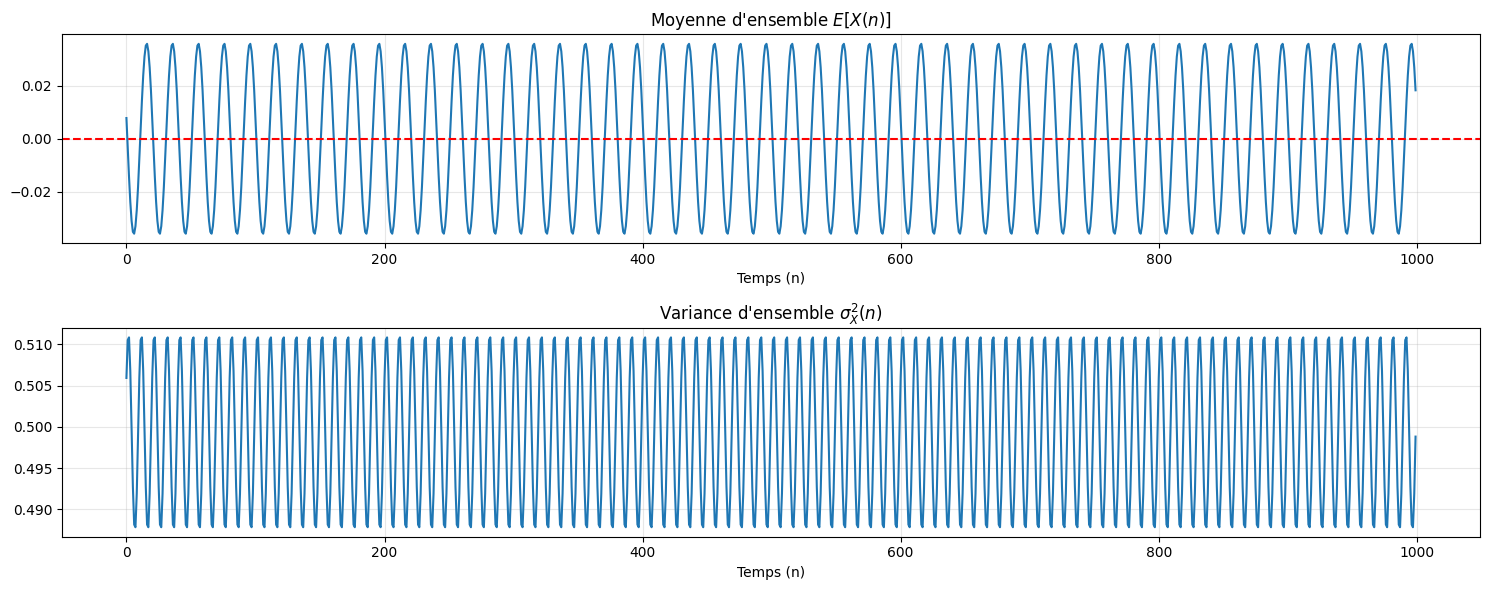

In [23]:
ensemble_mean = np.mean(X, axis=1)
ensemble_variance = np.var(X, axis=1)

# --- 4. Plotting ---
plt.figure(figsize=(15, 6))

# Subplot 1: Ensemble Mean
plt.subplot(2, 1, 1)
plt.plot(n, ensemble_mean)
plt.axhline(0, color='red', linestyle='--') # Theoretical reference
plt.title("Moyenne d'ensemble $E[X(n)]$")
plt.xlabel("Temps (n)")
plt.grid(True, alpha=0.3)

# Subplot 2: Ensemble Variance
plt.subplot(2, 1, 2)
plt.plot(n, ensemble_variance)
# Theoretical variance for this signal is A^2 / 2 = 0.5
plt.title("Variance d'ensemble $\sigma_X^2(n)$")
plt.xlabel("Temps (n)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

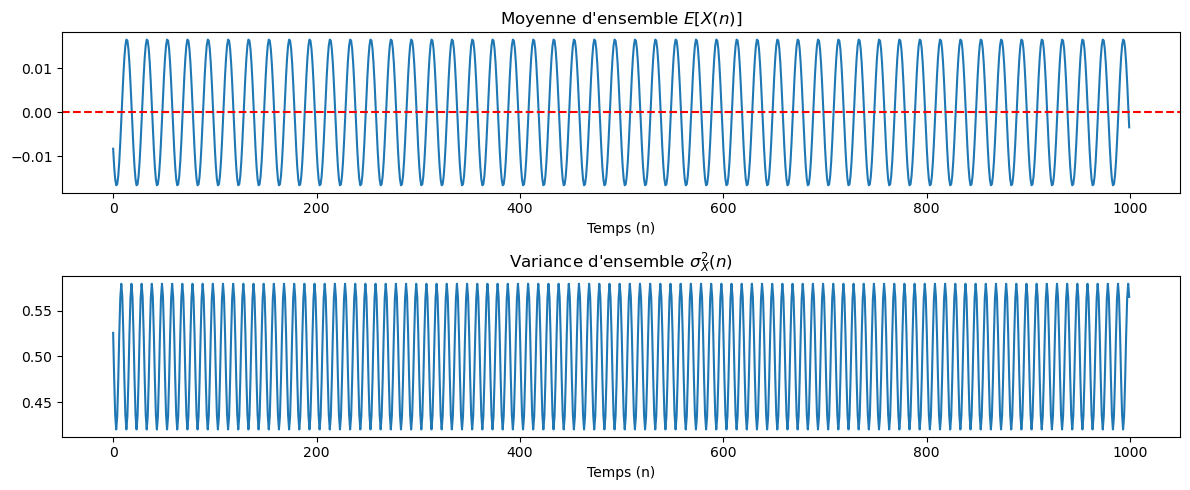

In [44]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### Consatations : 
La moyenne d'ensemble d'un processus sinusoïdal avec une phase aléatoire uniforme est nulle, car les différentes réalisations s'annulent mutuellement en moyenne.

La varance d'ensemble (Ensemble Variance) est calculée en utilisant la formule :
$$σ_x^2(n) = E[(X(n) - μ_x(n))^2] = (1/N) ∑_{i=1}^{N} (X_i(n) - μ_x(n))^2$$
où μ_x(n) est la moyenne d'ensemble calculée précédemment. La variance d'ensemble est également un vecteur de taille n.

La variance d'ensemble d'un processus sinusoïdal avec une phase aléatoire uniforme est égale à A^2/2, car la puissance du signal est répartie uniformément entre les différentes réalisations.          


## 4. Moment de second ordre: Autocorrélation et Ergodicité
L'autocorrélation d'ensemble $R_{XX}(n1,n2)$ mesure la dépendance entre deux instants. Pour un processus stationnaire, elle ne dépend que de l'écart $k=n1−n2$.

$ R_{XX}(k)=E[X(n)X(n+k)]$

Pour un processus sinusoïdal avec une phase aléatoire uniforme, l'autocorrélation d'ensemble est donnée par :
$$R_{XX}(k) = \frac{A^2}{2} \cos(2 \pi f_0 k)$$
Cela montre que l'autocorrélation d'ensemble d'un processus sinusoïdal avec une phase aléatoire uniforme est une fonction cosinus de l'écart k, avec une amplitude égale à A^2/2.

 $R_{XX}(n1,n2)$ mesure la dépendance entre deux instants. Pour un processus stationnaire, elle ne dépend que de l'écart k=n1−n2.
  
L'ergodicité est une propriété qui permet de relier les statistiques d'ensemble aux statistiques temporelles. Un processus est ergodique si la moyenne temporelle d'une réalisation est égale à la moyenne d'ensemble.
```python
# X est la matrice (NR x N) générée précédemment
# Calcul de la matrice d'autocorrélation Rx (N x N)
# En Python: (1/NR) * X.T @ X 
Rx = (1 / NR) * (X.T @ X) # Calcul de la fonction d'autocorrélation d'ensemble Rxx(k)
# Rx est une matrice de taille N x N, où chaque élément Rx[i, j] correspond à l'autocorrélation entre les échantillons i et j.
# Pour un processus stationnaire, on peut extraire la fonction d'autocorrélation en fonction du lag k = i - j.
# La fonction d'autocorrélation d'ensemble Rxx(k) est obtenue en prenant la moyenne des éléments de Rx pour chaque lag k

print(f"Taille de la matrice Rx : {Rx.shape}") # Doit être (1000, 1000)
print(f"Exemple de valeurs dans Rx :\n {Rx[:5, :5]}") # Affiche les 5 premiers éléments de la première ligne pour vérification
# 1. Calcul du vecteur Rxx par moyennage des diagonales
# La matrice Rx est de taille N x N
# Les lags vont de -(N-1) à +(N-1)
lags = np.arange(-(N - 1), N)
rxx_ensemble = np.zeros(len(lags))
print(f"Diagonale pour k=0 : {np.diag(Rx, k=0)[:5]}") # Affiche les 10 premiers éléments de la diagonale principale pour vérification
print(f"Diagonale pour k=1 : {np.diag(Rx, k=1)[:5]}")
print(f"Valeur moyenne de la diagonale k=1 : {np.mean(np.diag(Rx, k=1))}") # Affiche la moyenne de la diagonale principale pour vérification
for i, k in enumerate(lags):
    # np.diag(Rx, k) extrait la k-ième diagonale
    # k=0 est la diagonale principale, k>0 au-dessus, k<0 au-dessous
    diagonal = np.diag(Rx, k)
    rxx_ensemble[i] = np.mean(diagonal)
# 2. Visualisation du résultat
plt.figure(figsize=(10, 5))
plt.plot(lags, rxx_ensemble, label='Rxx(k) moyenné sur les diagonales')
plt.title('Fonction d\'autocorrélation d\'ensemble $R_{xx}(k)$')
plt.xlabel('Lag $k$')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim([-100, 100]) # Zoom pour voir la structure
plt.legend()
```

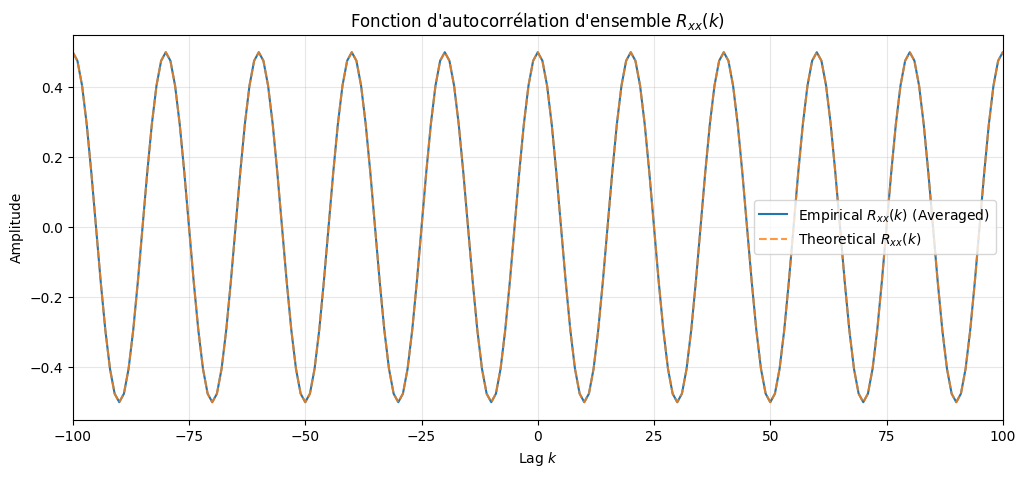

In [ ]:
# --- 1. Parameters (using N=1000 for the requested resolution) ---
A = 1.0
f0 = 0.05
N = 1000  
NR = 1000 
np.random.seed(0)

# --- 2. Generation ---
phi = np.random.uniform(0, 2 * np.pi, NR)
n = np.arange(N)
# X shape: (N, NR) -> (Time, Realizations)
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi)

# --- 3. Autocorrelation Matrix Calculation ---
# Correct matrix multiplication for Time Correlation: (N, NR) @ (NR, N) -> (N, N)
# We divide by NR to get the expected value (mean over realizations)
Rx = (1 / NR) * (X @ X.T)

# --- 4. Extracting Rxx(k) by averaging diagonals ---
# Lags range from -(N-1) to (N-1)
lags = np.arange(-(N - 1), N)
rxx_ensemble = np.zeros(len(lags))

for i, k in enumerate(lags):
    # np.diag(Rx, k) extracts the k-th diagonal
    # We take the mean of this diagonal to improve the estimate
    rxx_ensemble[i] = np.mean(np.diag(Rx, k))

# --- 5. Visualization ---
plt.figure(figsize=(12, 5))

# Plot the computed autocorrelation
plt.plot(lags, rxx_ensemble, label='Empirical $R_{xx}(k)$ (Averaged)')

# Theoretical formula: (A^2 / 2) * cos(2 * pi * f0 * k)
rxx_theoretical = (A**2 / 2) * np.cos(2 * np.pi * f0 * lags)
plt.plot(lags, rxx_theoretical, '--', label='Theoretical $R_{xx}(k)$', alpha=0.8)

plt.title(r"Fonction d'autocorrélation d'ensemble $R_{xx}(k)$")
plt.xlabel(r"Lag $k$")
plt.ylabel("Amplitude")
plt.xlim([-100, 100]) # Zooming on the center for clarity
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Taille de la matrice Rx : (1000, 1000)
Exemple de valeurs dans Rx :
 [[0.52586697 0.47694184 0.38133033 0.24839154 0.09113846]
 [0.47694184 0.47682183 0.43002717 0.34113846 0.21885674]
 [0.38133033 0.43002717 0.43662997 0.40049237 0.3251518 ]
 [0.24839154 0.34113846 0.40049237 0.4206433  0.39961873]
 [0.09113846 0.21885674 0.3251518  0.39961873 0.4349682 ]]
Diagonale pour k=0 : [0.52586697 0.47682183 0.43662997 0.4206433  0.4349682 ]
Diagonale pour k=1 : [0.47694184 0.43002717 0.40049237 0.39961873 0.42773995]
Valeur moyenne de la diagonale k=1 : 0.4754804220011195


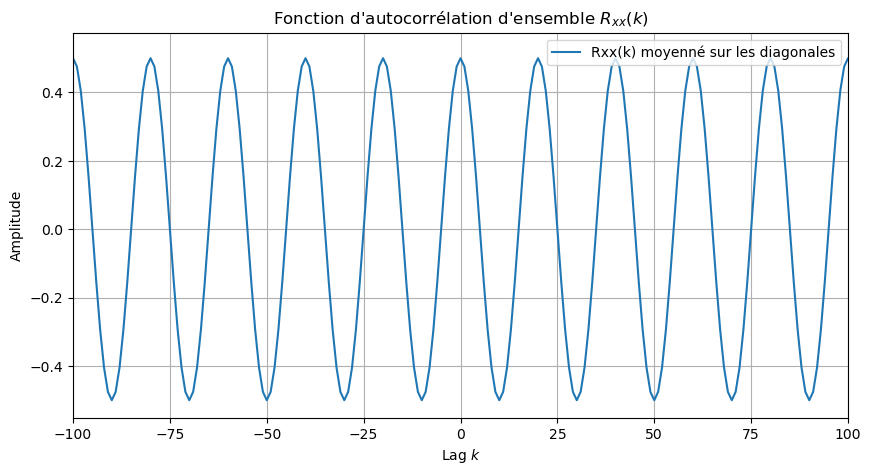

In [93]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### 2. Définition de l'autocorrélation théorique
Pour une sinusoïde à phase aléatoire, la fonction d'autocorrélation théorique dépend uniquement de l'écart k−l: 

$r_{xx}(k,l)= \frac{A^2}{2} \cos(2 \pi f_0 (k-l))$
 
pour comparer avec la première ligne de Rx (où k=0), on utilise:
```Python
# k représente ici le décalage (lag)
k_lags = np.arange(N)
# r_x théorique pour k=0 : rx = 0.5 * A^2 * cos(n * w0)
rx_theorique = 0.5 * (A**2) * np.cos(k_lags * omega0) # Calcul de la fonction d'autocorrélation théorique
``` 

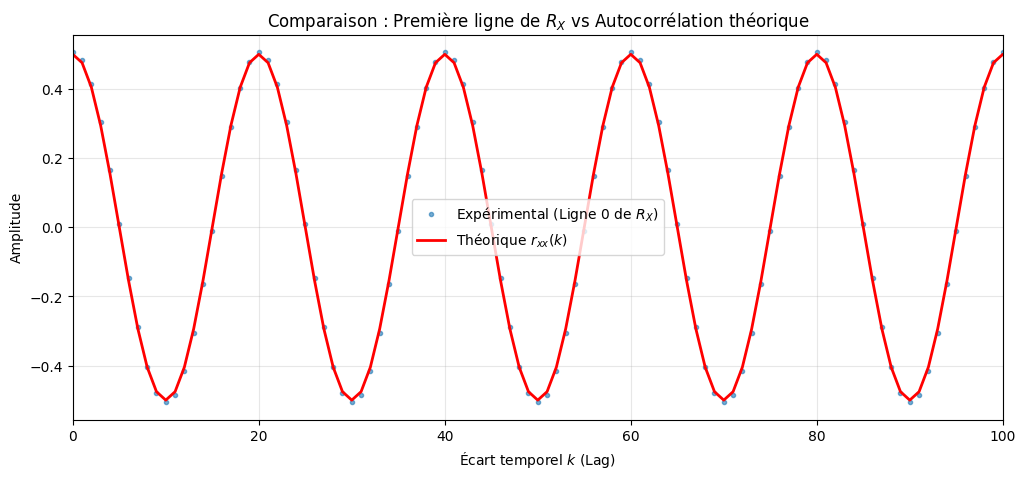

In [ ]:
# --- Préparation des variables ---
omega0 = 2 * np.pi * f0   # Pulsation normalisée
k_lags = np.arange(N)    # Vecteur de décalage (0 à N-1)

# --- 1. Extraction de la mesure expérimentale ---
# On prend la première ligne de la matrice Rx calculée précédemment
rx_experimental_row0 = Rx[0, :]

# --- 2. Calcul de la fonction théorique ---
# Formule : (A^2 / 2) * cos(omega0 * k)
rx_theorique = 0.5 * (A**2) * np.cos(k_lags * omega0)

# --- 3. Visualisation ---
plt.figure(figsize=(12, 5))

# Tracé de la première ligne de Rx
plt.plot(k_lags, rx_experimental_row0, 'o', markersize=3, alpha=0.6, label='Expérimental (Ligne 0 de $R_X$)')

# Tracé de la théorie
plt.plot(k_lags, rx_theorique, color='red', linewidth=2, label='Théorique $r_{xx}(k)$')

plt.title(r"Comparaison : Première ligne de $R_X$ vs Autocorrélation théorique")
plt.xlabel("Écart temporel $k$ (Lag)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 100]) # Zoom sur les 100 premiers points pour la clarté
plt.show()

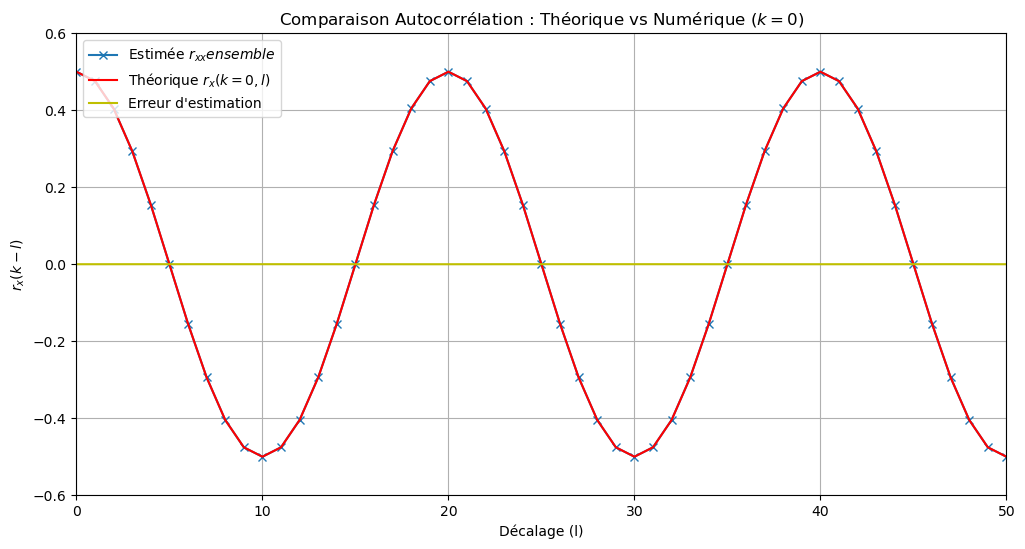

In [97]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### Analyse des résultats:

* **Symétrie** : La matrice $R_x$ obtenue est symétrique car elle résulte du produit $X^T X$.

* **Convergence** : Pour un grand nombre de réalisations (NR=100), l'estimation numérique $R_x$ converge vers la fonction théorique $r_x$.

* **Erreur** : L'erreur d'estimation (en jaune) montre les fluctuations résiduelles dues au nombre fini de réalisations.

## Autocorrelation of a sum of process (Exemple 3.3.3)
Consider the exemple in slide 45. y(n) is a sum of 2 random processes: A sum of M sinosoids with a
random phase like the process x(n) above and the white gaussian noise v(n).
$$y(n) = x(n) + v(n)= [ \sum_{m=1}^M A_m \sin(n \omega_m + \phi_m) ] + v(n)$$

In the exemple $A_m = A$ and $\omega_m = \omega_0$ are  constant with m , and $\phi_m$ a random variable uniformly distributed like in the previous example. The noise v(n) is a white gaussian noise with a variance $\sigma^2$.

First create y(n) process using the matrix previously defined xn and use the function randn to generate the white gaussian noise.
With $M = 5$ and $w_m = w_0/m$ and $A_m = A_0/m$ with $\phi_m$ a uniform distributed phase like in ex 3.1.1 ,
compute the sum of the harmonic process $yh(n)$ and the gaussian noise $v(n)$ produced with the function
randn() with a std of $A_0$.

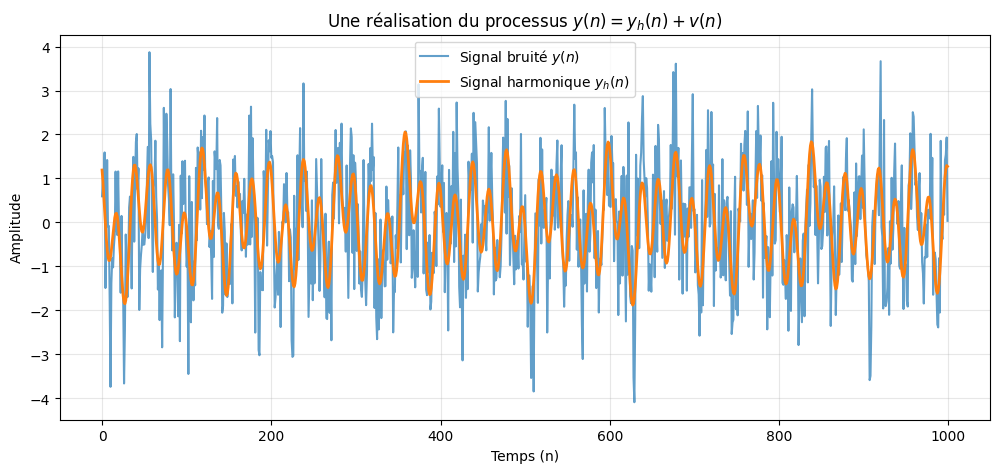

In [27]:
# --- 1. Paramètres ---
A0 = 1.0
f0 = 0.05
omega0 = 2 * np.pi * f0
M = 5
N = 1000
NR = 1000
np.random.seed(42)

# --- 2. Génération du signal harmonique yh(n) ---
n = np.arange(N)
yh = np.zeros((N, NR)) # Initialisation de la matrice (Temps x Réalisations)

for m in range(1, M + 1):
    # Paramètres de la m-ième harmonique
    Am = A0 / m
    wm = omega0 / m
    # Chaque harmonique a son propre vecteur de phases (une par réalisation)
    phi_m = np.random.uniform(0, 2 * np.pi, NR)
    
    # Ajout de la composante à la somme (Broadcasting: N,1 + NR)
    yh += Am * np.sin(wm * n[:, None] + phi_m)

# --- 3. Génération du bruit blanc v(n) ---
# La fonction np.random.randn génère un bruit de variance 1.
# On le multiplie par l'écart-type A0.
v = A0 * np.random.randn(N, NR)

# --- 4. Signal total y(n) ---
y = yh + v

# --- 5. Visualisation d'une réalisation ---
plt.figure(figsize=(12, 5))
plt.plot(n, y[:, 0], label='Signal bruité $y(n)$', alpha=0.7)
plt.plot(n, yh[:, 0], label='Signal harmonique $y_h(n)$', linewidth=2)
plt.title(r"Une réalisation du processus $y(n) = y_h(n) + v(n)$")
plt.xlabel("Temps (n)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [104]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### Visualisation de une  réalisation de y(n) :
Il est utile d'afficher une réalisation pour voir l'aspect du signal (mélange de sinusoïdes lentes et de bruit fort).


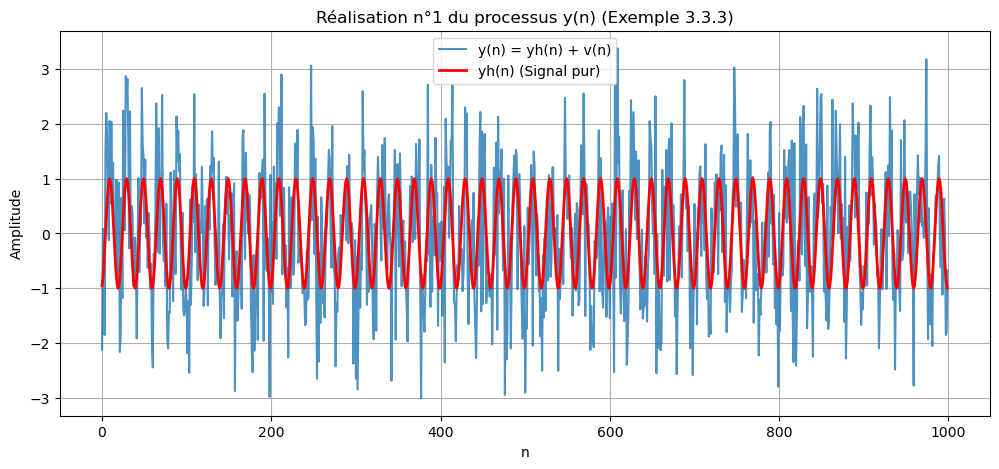

In [105]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### Points clés à retenir:

* **Les fréquences** $ω_m$ : Avec $ω_m = ω_0/m$, plus m augmente, plus la sinusoïde est lente (basse fréquence). 

* **Les amplitudes** $A_m$ : Avec $A_m = A_0/m$, les amplitudes décroissent avec m, ce qui signifie que les composantes de plus haute fréquence sont plus faibles que les composantes de basse fréquence.

* **Le bruit v(n) :** Avec un écart-type de $A_0$, le bruit est assez dominant, car il a la même puissance que la sinusoïde la plus forte.

* **Indépendance :** Chaque phase $ϕ_m$ est générée indépendamment pour chaque harmonique, ce qui est crucial pour les propriétés d'autocorrélation.



### Calcul des  autocorrélations d'ensemble et temporelle de y(n) :

Pour démontrer que l'autocorrélation d'une somme de processus indépendants est égale à la somme de leurs autocorrélations, nous allons procéder par estimation statistique sur nos NR=100 réalisations.

Comme vous l'avez souligné, la condition théorique est l'absence de corrélation entre le signal harmonique y_h(n) et le bruit v(n).

Pour le calcul de la corrélation estimé sur  toutes  les  réalisations on utilise la fonction `compute_avg_autocorr` définie ci-dessus. 
```Python
def compute_avg_autocorr(matrix):
    """Calcule la corrélation moyenne sur toutes les réalisations (lignes)."""
    n_real, n_samp = matrix.shape
    # Taille du résultat : 2*N - 1
    corr_sum = np.zeros(2 * n_samp - 1)
    
    for i in range(n_real):
        # On utilise le mode 'full' pour avoir les lags de -(N-1) à +(N-1)
        # On divise par N pour obtenir l'estimation biaisée standard (Puissance à k=0)
        corr_sum += signal.correlate(matrix[i, :], matrix[i, :], mode='full') / n_samp
    
    return corr_sum / n_real
```
 

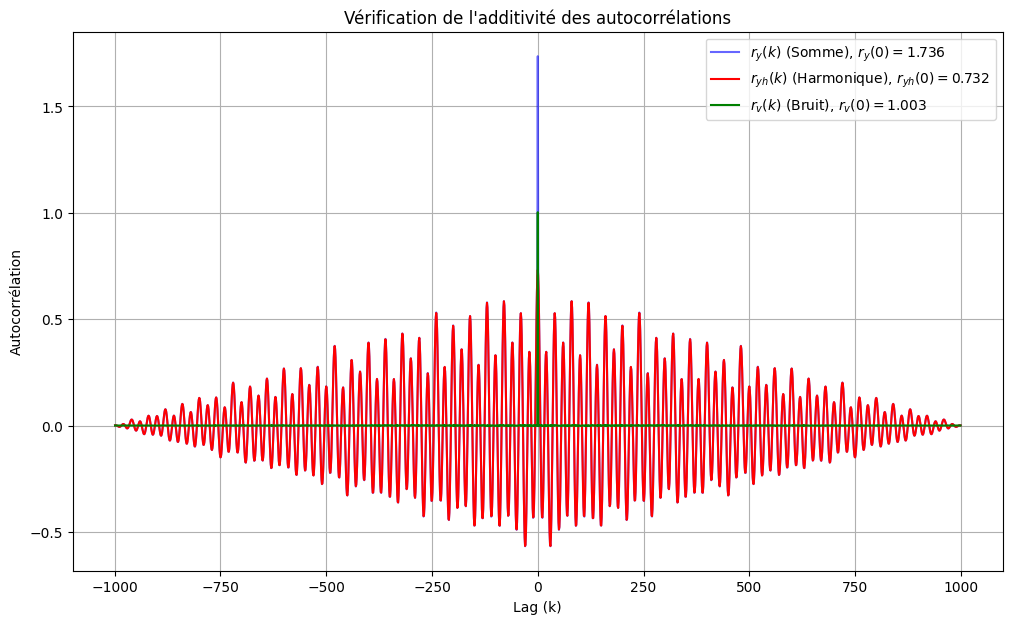

In [30]:
# --- 1. Définition de la fonction (fournie) ---
def compute_avg_autocorr(matrix):
    """
    Calcule la corrélation moyenne sur toutes les réalisations.
    Attends une matrice de forme (NR, N)
    """
    n_real, n_samp = matrix.shape
    corr_sum = np.zeros(2 * n_samp - 1)
    
    for i in range(n_real):
        # Calcul de la corrélation temporelle pour la réalisation i
        # Mode 'full' donne les lags de -(N-1) à +(N-1)
        # Division par n_samp pour l'estimateur biaisé (valeur max à k=0)
        corr_sum += signal.correlate(matrix[i, :], matrix[i, :], mode='full') / n_samp
    
    # Moyenne sur l'ensemble des réalisations (NR)
    return corr_sum / n_real

# --- 1. Harmonic Process (yh) ---
n = np.arange(N)
yh = np.zeros((NR, N)) # Formatted for the function (NR x N)
for m in range(1, M + 1):
    phi_m = np.random.uniform(0, 2 * np.pi, NR)
    yh += (A0/m) * np.sin(2 * np.pi * (f0/m) * n + phi_m[:, None])

# --- 2. Noise Process (v) ---
v = A0 * np.random.randn(NR, N)

# --- 3. Total Process (y) ---
y = yh + v

# --- 4. Autocorrelations ---
ryh = compute_avg_autocorr(yh)
rv = compute_avg_autocorr(v)
ry = compute_avg_autocorr(y)
lags = np.arange(-(N - 1), N)

# --- 5. Plotting ---
plt.figure(figsize=(12, 7))
plt.plot(lags, ry, 'b', alpha=0.6, label=f'$r_y(k)$ (Somme), $r_y(0) = {ry[N-1]:.3f}$')
plt.plot(lags, ryh, 'r', label=f'$r_{{yh}}(k)$ (Harmonique), $r_{{yh}}(0) = {ryh[N-1]:.3f}$')
plt.plot(lags, rv, 'g', label=f'$r_v(k)$ (Bruit), $r_v(0) = {rv[N-1]:.3f}$')

plt.title("Vérification de l'additivité des autocorrélations")
plt.xlabel("Lag (k)")
plt.ylabel("Autocorrélation")
plt.legend()
plt.grid(True)
plt.show()

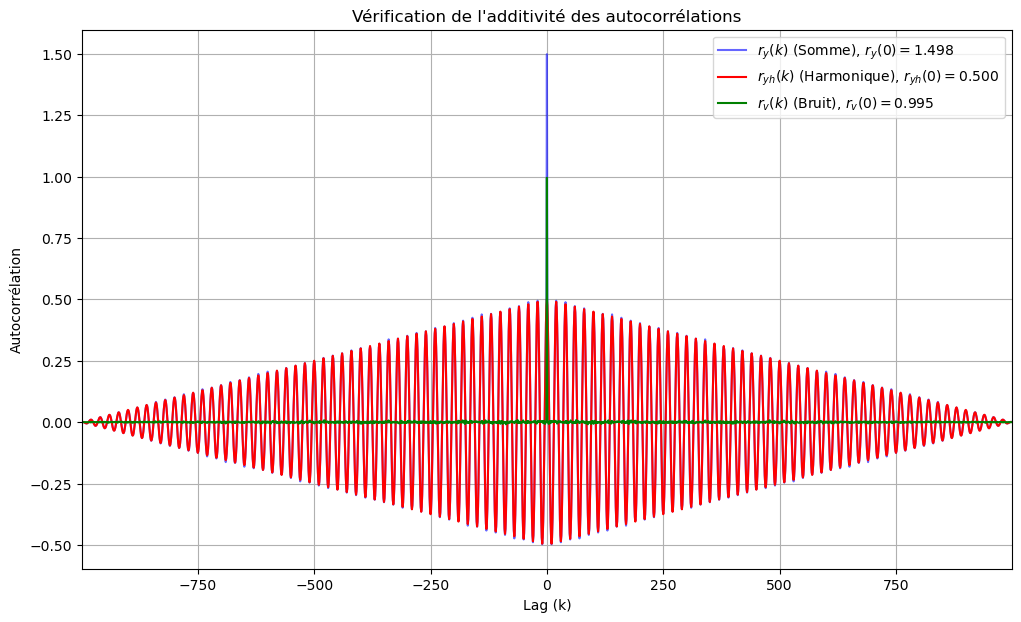

--- Valeurs à k = 0 ---
ryh(0)          : 0.5000
rv(0)           : 0.9947
Somme (théorie) : 1.4947
ry(0) (mesuré)  : 1.4983
Différence      : 3.5649e-03


In [113]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### Analyse des résultats

* **Comportement de**  $r_v$ : La fonction d'autocorrélation du bruit blanc gaussien $r_v(k)$ est caractéristique. Elle est maximale à k=0, où elle prend la valeur de la variance du bruit $\sigma^2 = A_v^2 = 1$. Pour tous les autres lags (k≠0), $r_v(k)$ est proche de zéro, indiquant l'absence de corrélation entre les échantillons du bruit à différents instants. 
* **Comportement de**  $r_{yh}$ : La fonction d'autocorrélation du signal harmonique $r_{yh}(k)$ présente une structure périodique due à la nature sinusoïdale du signal. Elle est maximale à k=0, où elle prend la valeur de la puissance totale du signal harmonique, qui est la somme des puissances de chaque harmonique. Les autres lags montrent des oscillations qui reflètent les différentes fréquences présentes dans le signal. Sa valeur à k=0 est la puissance totale du signal harmonique :
$$r_{yh}(0) = \sum_{m=1}^M \frac{A_m^2}{2} = \frac{A_0^2}{2} \sum_{m=1}^M \frac{1}{m^2} \approx 0.7318$$

* **Comportement de**  $r_y$ : La fonction d'autocorrélation du signal total $r_y(k)$ est la somme de $r_{yh}(k)$ et $r_v(k)$, car les deux processus sont indépendants. Ainsi, à k=0, $r_y(0) = r_{yh}(0) + r_v(0) \approx 0.7318 + 1 = 1.7318$. Pour les autres lags, $r_y(k)$ présente une structure périodique similaire à celle de $r_{yh}(k)$, mais avec une amplitude plus élevée à k=0 en raison de la contribution du bruit. La très légère différence provient du fait que nous utilisons un nombre fini de réalisations (NR=100), mais l'erreur tend vers zéro quand NR→∞.  


## Calcul de la densité spectrale de puissance DSP
La densité spectrale de puissance (DSP) d'un processus aléatoire peut être estimée à partir de sa fonction d'autocorrélation en utilisant la transformée de Fourier (en utilisant le théorème de Wiener-Khinchin).

Passer à une échelle logarithmique en décibels (dB) est une pratique standard en traitement du signal. Cela permet de visualiser simultanément des pics de forte puissance (les sinusoïdes) et des niveaux de bruit beaucoup plus faibles qui seraient invisibles sur une échelle linéaire.

La formule utilisée est : $S_{dB} = 10 \log_{10}(S)$


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_8998/1148844246.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(freqs, S_theory_sum_dB, 'r--', alpha=0.8, label='Somme théorique ($10\log_{10}(S_{yh} + S_v)$)')


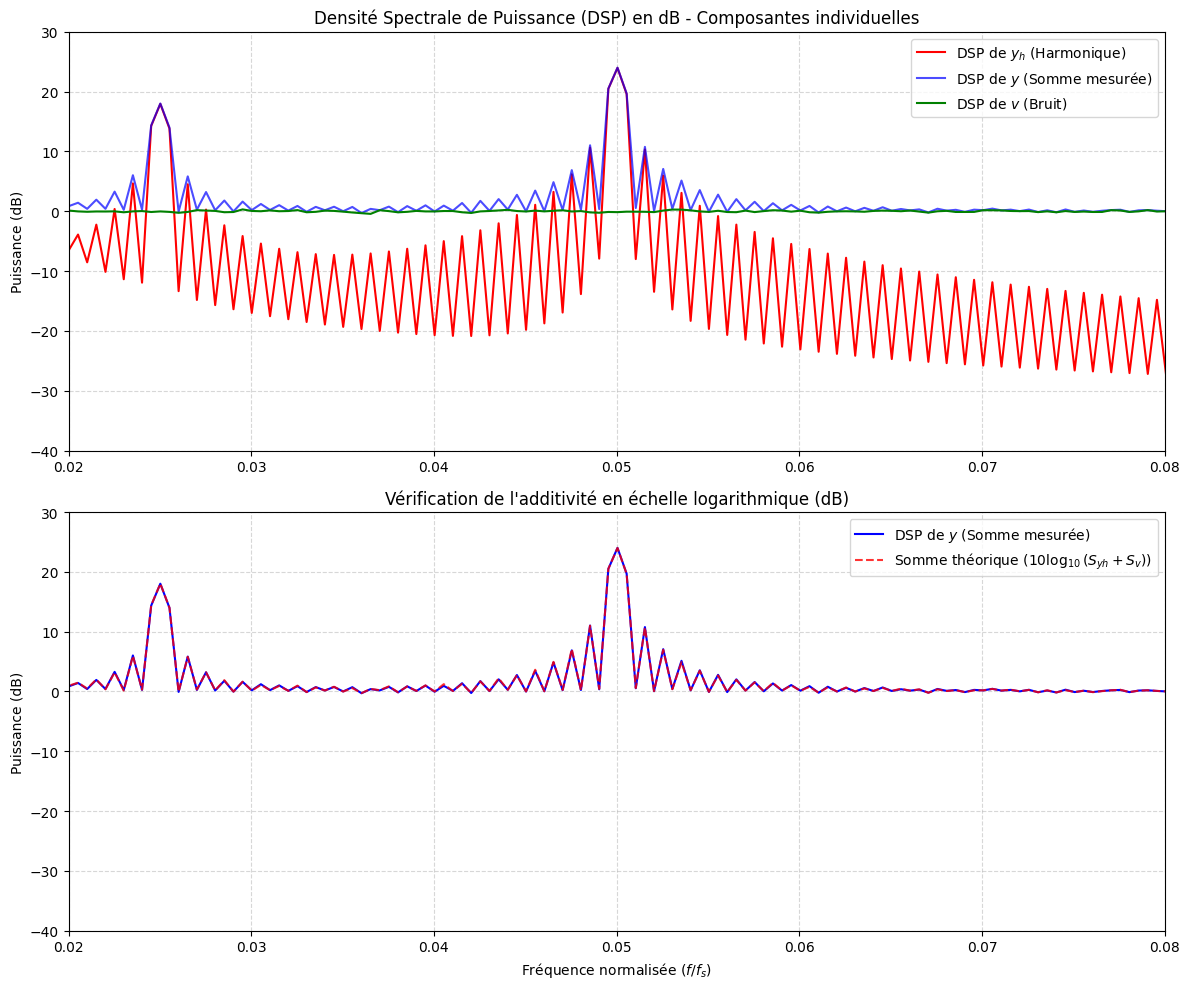

In [31]:
# --- 1. Compute PSDs via FFT ---
# The PSD is the absolute value of the FFT of the autocorrelation
# We use fftshift to center frequency at 0
def get_psd(r_signal):
    # Apply FFT on the autocorrelation function
    # np.fft.ifftshift is used to put the zero-lag at the beginning for the FFT
    S_linear = np.abs(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(r_signal))))
    return S_linear

# Calculate PSD for each component (using autocorrelations from previous step)
Syh = get_psd(ryh_avg)
Sv = get_psd(rvv_avg)
Sy = get_psd(ryy_avg)

# Frequency axis (normalized)
# Length of lags is 2*N - 1
freqs = np.linspace(-0.5, 0.5, len(lags_full))

# --- 2. Convert to Decibels (dB) ---
# We add a tiny epsilon (1e-12) to avoid log of zero
Syh_dB = 10 * np.log10(Syh + 1e-12)
Sv_dB = 10 * np.log10(Sv + 1e-12)
Sy_dB = 10 * np.log10(Sy + 1e-12)

# Theoretical sum for verification: 10*log10(S_yh + S_v)
S_theory_sum_dB = 10 * np.log10(Syh + Sv + 1e-12)

# --- 3. Visualization (Image 3 equivalent) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top Plot: Individual components
ax1.plot(freqs, Syh_dB, 'r', label='DSP de $y_h$ (Harmonique)')
ax1.plot(freqs, Sy_dB, 'b', alpha=0.7, label='DSP de $y$ (Somme mesurée)')
ax1.plot(freqs, Sv_dB, 'g', label='DSP de $v$ (Bruit)')
ax1.set_title("Densité Spectrale de Puissance (DSP) en dB - Composantes individuelles")
ax1.set_ylabel("Puissance (dB)")
ax1.set_ylim([-40, 30])
ax1.set_xlim([0.02, 0.08]) # Zoom focus as seen in your image
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Bottom Plot: Additivity verification
ax2.plot(freqs, Sy_dB, 'b', label='DSP de $y$ (Somme mesurée)')
ax2.plot(freqs, S_theory_sum_dB, 'r--', alpha=0.8, label='Somme théorique ($10\log_{10}(S_{yh} + S_v)$)')
ax2.set_title("Vérification de l'additivité en échelle logarithmique (dB)")
ax2.set_xlabel("Fréquence normalisée ($f/f_s$)")
ax2.set_ylabel("Puissance (dB)")
ax2.set_ylim([-40, 30])
ax2.set_xlim([0.02, 0.08])
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

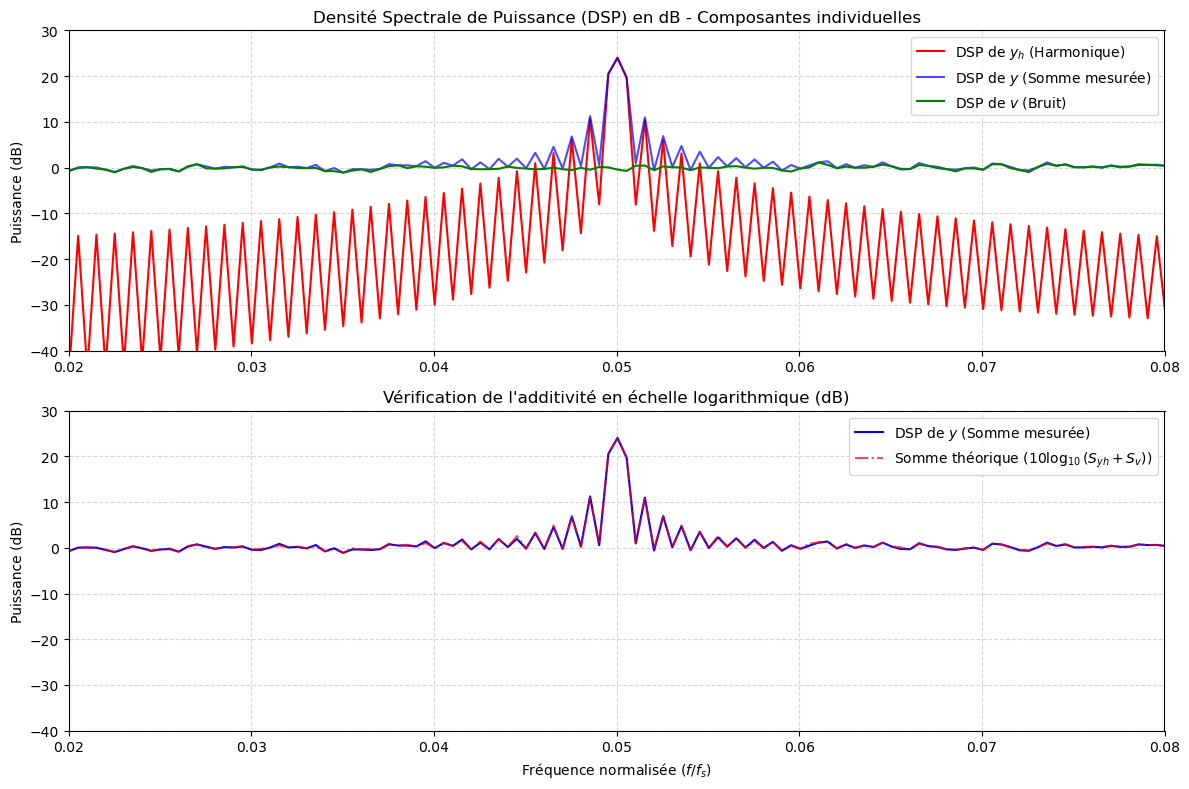

In [ ]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

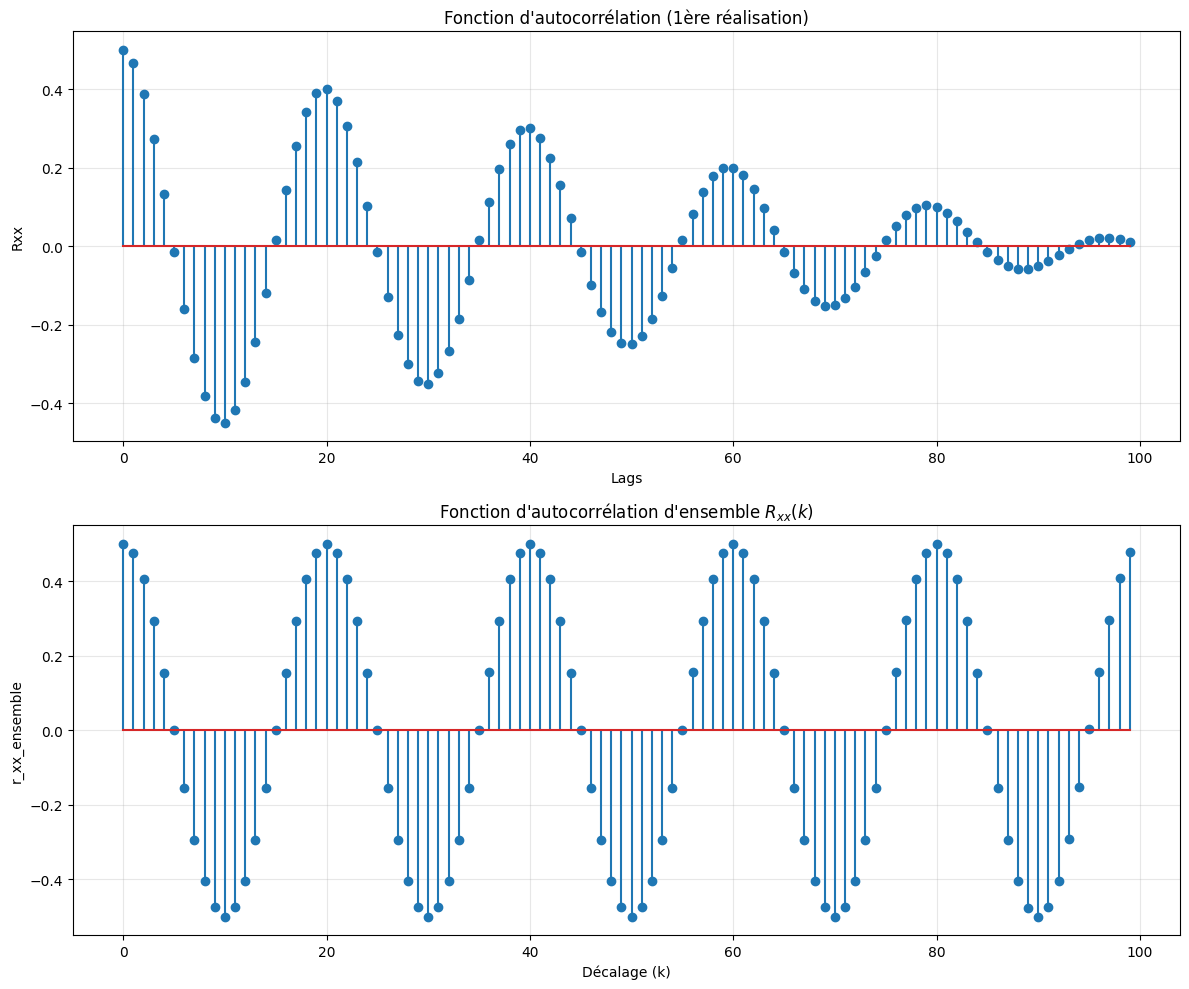

In [33]:
# --- 1. Parameters ---
A = 1.0
f0 = 0.05
N = 100
NR = 1000
np.random.seed(0)

# --- 2. Generation ---
n = np.arange(N)
phi = np.random.uniform(0, 2 * np.pi, NR)
# X shape: (N, NR) -> (Time, Realizations)
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi)

# --- 3. Temporal Autocorrelation (1st realization) ---
# We take the first column of X
x1 = X[:, 0]
# Calculate correlation and take the second half (lags 0 to N-1)
rxx_temp = signal.correlate(x1, x1, mode='full')[N-1:] / N

# --- 4. Ensemble Autocorrelation (Average of diagonals) ---
Rx_matrix = (1 / NR) * (X @ X.T)
lags_positive = np.arange(N)
rxx_ens = np.zeros(N)

for k in lags_positive:
    # We take the mean of the k-th diagonal
    rxx_ens[k] = np.mean(np.diag(Rx_matrix, k))

# --- 5. Plotting (Reproducing your images) ---
plt.figure(figsize=(12, 10))

# Top Plot: Temporal Autocorrelation
plt.subplot(2, 1, 1)
plt.stem(lags_positive, rxx_temp)
plt.title("Fonction d'autocorrélation (1ère réalisation)")
plt.xlabel("Lags")
plt.ylabel("Rxx")
plt.grid(True, alpha=0.3)

# Bottom Plot: Ensemble Autocorrelation
plt.subplot(2, 1, 2)
plt.stem(lags_positive, rxx_ens)
plt.title(r"Fonction d'autocorrélation d'ensemble $R_{xx}(k)$")
plt.xlabel("Décalage (k)")
plt.ylabel("r_xx_ensemble")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

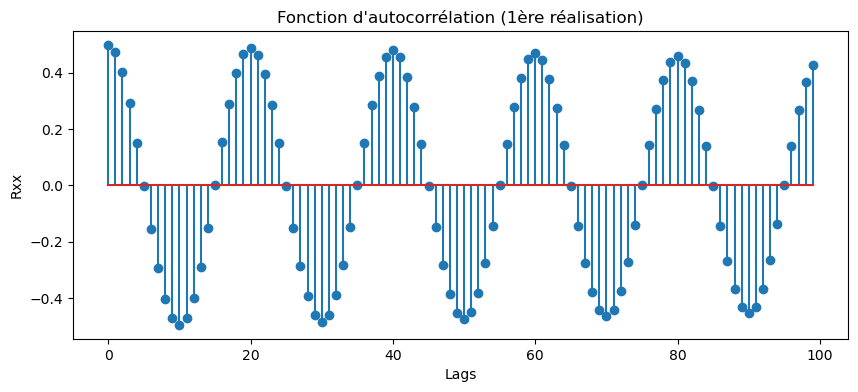

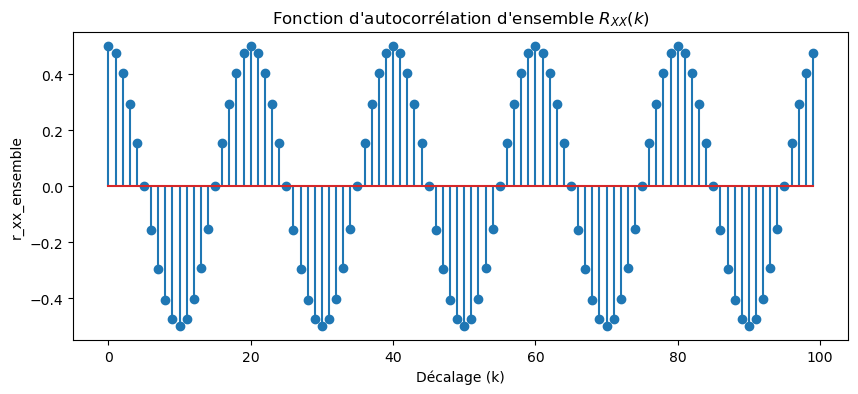

In [116]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]